# Resume Screening / Classification — 03 Model Building

TF-IDF (unigrams+bigrams) feeds six classic-ML classifiers — Multinomial & Complement Naive Bayes, Logistic Regression, Linear SVM, Ridge, and Passive-Aggressive. We compare them, tune the best, and show a prediction. All numbers are produced by running the code.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
import utils

df=pd.read_csv('data/resumes_cleaned.csv').dropna(subset=['clean_text','label'])
print('rows:',len(df),'| classes:',df['label'].nunique())

rows: 962 | classes: 25


## 1. TF-IDF features + train/test split

In [2]:
X_tr,X_te,y_tr,y_te=train_test_split(df['clean_text'],df['label'],test_size=0.2,random_state=42,stratify=df['label'])
vec=TfidfVectorizer(max_features=20000,ngram_range=(1,2),sublinear_tf=True)
Xtr=vec.fit_transform(X_tr); Xte=vec.transform(X_te)
print('TF-IDF:',Xtr.shape)

TF-IDF: (769, 20000)


## 2. Train & compare six classifiers

In [3]:
results=[]
for name,model in utils.get_models().items():
    model.fit(Xtr,y_tr); pred=model.predict(Xte)
    results.append(utils.evaluate_model(name,y_te,pred))
res_df=utils.compare_models(results)
res_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,1.0000,1.0000,1.0000,1.0000
1,Passive Aggressive,1.0000,1.0000,1.0000,1.0000
2,Ridge Classifier,0.9948,0.9957,0.9948,0.9949
3,Complement NB,0.9948,0.9956,0.9948,0.9947
4,Logistic Regression,0.9896,0.9907,0.9896,0.9895
5,Multinomial NB,0.9534,0.9652,0.9534,0.9483


## 3. Comparison chart

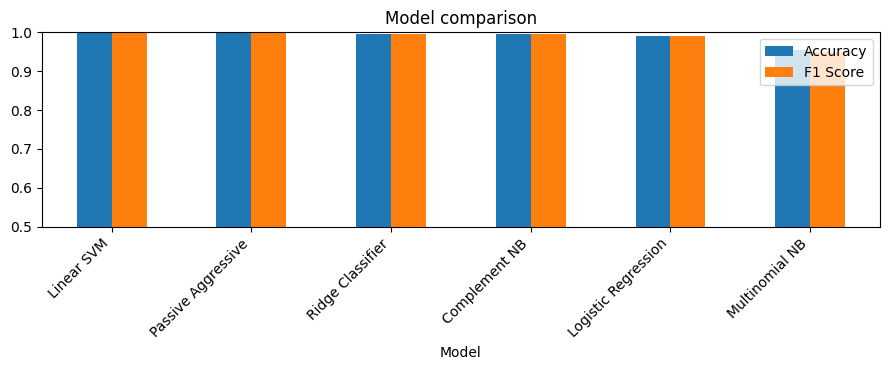

In [4]:
fig,ax=plt.subplots(figsize=(9,3.8))
res_df.set_index('Model')[['Accuracy','F1 Score']].plot(kind='bar',ax=ax); ax.set_title('Model comparison'); ax.set_ylim(min(0.5,res_df['F1 Score'].min()-0.05),1.0); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()

## 4. Confusion matrix (best model)

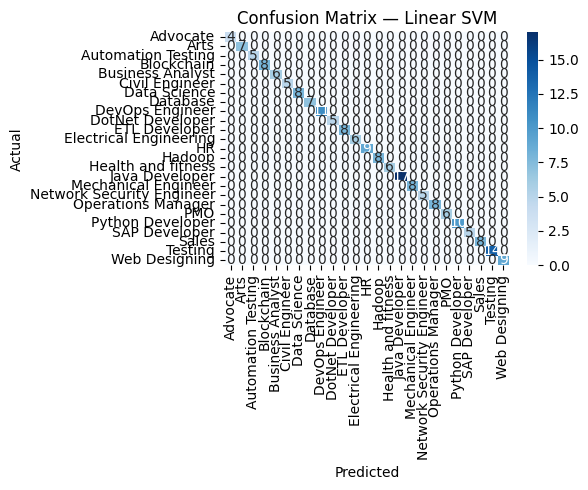

In [5]:
best_name=res_df.iloc[0]['Model']
best=utils.get_models()[best_name]; best.fit(Xtr,y_tr); pred=best.predict(Xte)
fig,ax=plt.subplots(figsize=(6,5))
utils.plot_confusion_matrix(y_te,pred,best_name,labels=sorted(df['label'].unique()),ax=ax); plt.tight_layout(); plt.show()

## 5. Tune Logistic Regression (C)

In [6]:
gs=GridSearchCV(LogisticRegression(max_iter=1000),{'C':[0.1,1,10]},cv=3,scoring='f1_weighted',n_jobs=-1)
gs.fit(Xtr,y_tr)
from sklearn.metrics import f1_score,accuracy_score
tp=gs.best_estimator_.predict(Xte)
print('best C:',gs.best_params_['C'])
print('tuned accuracy: %.4f'%accuracy_score(y_te,tp))
print('tuned weighted F1: %.4f'%f1_score(y_te,tp,average='weighted'))

best C: 10
tuned accuracy: 1.0000
tuned weighted F1: 1.0000


## 6. Prediction example

In [7]:
sample=X_te.iloc[0]
print('text :',str(sample)[:160])
print('true :',y_te.iloc[0])
print('pred :',best.predict(vec.transform([sample]))[0])

text : education details january bachelor engineering extc mumbai maharashtra mumbai university january diploma industrial electronics vashi maharashtra fr agnel polyt
true : ETL Developer
pred : ETL Developer


## 7. Summary

The comparison table and confusion matrix above are the real, executed results. TF-IDF + a linear classifier is a strong, fast baseline for text classification; the best model and tuned Logistic Regression scores are reported in the project README.